In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# The Excel file has extra header rows — skip them and set row 3 as header
import pandas as pd

df = pd.read_excel('/content/drive/MyDrive/Portafolip/Adidas US Sales Datasets.xlsx',
                   skiprows=3,      # skip first 3 empty rows
                   header=1)        # row 4 (index 1) is the real header

# Drop the first unnamed column
df = df.drop(columns=df.columns[0])

# Preview
print(df.shape)
print(df.columns)
df.head()

(9648, 13)
Index(['Retailer', 'Retailer ID', 'Invoice Date', 'Region', 'State', 'City',
       'Product', 'Price per Unit', 'Units Sold', 'Total Sales',
       'Operating Profit', 'Operating Margin', 'Sales Method'],
      dtype='object')


,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,600000.0,300000.0,0.50,In-store
1,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,500000.0,150000.0,0.30,In-store
2,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,400000.0,140000.0,0.35,In-store
3,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,382500.0,133875.0,0.35,In-store
4,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,540000.0,162000.0,0.30,In-store


In [3]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Retailer          9648 non-null   object        
 1   Retailer ID       9648 non-null   int64         
 2   Invoice Date      9648 non-null   datetime64[ns]
 3   Region            9648 non-null   object        
 4   State             9648 non-null   object        
 5   City              9648 non-null   object        
 6   Product           9648 non-null   object        
 7   Price per Unit    9648 non-null   float64       
 8   Units Sold        9648 non-null   int64         
 9   Total Sales       9648 non-null   float64       
 10  Operating Profit  9648 non-null   float64       
 11  Operating Margin  9648 non-null   float64       
 12  Sales Method      9648 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(2), object(6)
memory usage: 980.0+ KB


In [4]:
# Convert Invoice Date to datetime and extract month
# We need monthly aggregated sales per product for time series forecasting
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'])
df['Month'] = df['Invoice Date'].dt.to_period('M')

# Aggregate Units Sold by Month and Product
monthly_sales = df.groupby(['Month', 'Product'])['Units Sold'].sum().reset_index()
monthly_sales.columns = ['Month', 'Product', 'Units_Sold']

# Preview
print("Products available:")
print(monthly_sales['Product'].unique())
print("\nDate range:")
print(f"From: {monthly_sales['Month'].min()} | To: {monthly_sales['Month'].max()}")
print("\nShape:", monthly_sales.shape)
monthly_sales.head(12)

Products available:
["Men's Apparel" "Men's Athletic Footwear" "Men's Street Footwear"
 "Women's Apparel" "Women's Athletic Footwear" "Women's Street Footwear"]

Date range:
From: 2020-01 | To: 2021-12

Shape: (144, 3)


,Month,Product,Units_Sold
0,2020-01,Men's Apparel,5902
1,2020-01,Men's Athletic Footwear,7791
2,2020-01,Men's Street Footwear,11919
3,2020-01,Women's Apparel,8489
4,2020-01,Women's Athletic Footwear,6261
5,2020-01,Women's Street Footwear,7971
6,2020-02,Men's Apparel,5400
7,2020-02,Men's Athletic Footwear,7694
8,2020-02,Men's Street Footwear,7205
9,2020-02,Women's Apparel,4641


### Dataset Overview

The dataset contains **6 product categories** across **24 months** (Jan 2020 — Dec 2021),
resulting in 144 observations (6 products × 24 months).

All products are footwear and apparel — similar to a sports fashion retailer like Joma.
No missing values were found, the dataset is clean and ready for forecasting.

In [5]:
# Which product has the highest total sales across all months?


total_by_product = monthly_sales.groupby('Product')['Units_Sold'].sum().sort_values(ascending=False)
print("Total Units Sold by Product (all months):")
print(total_by_product)

Total Units Sold by Product (all months):
Product
Men's Street Footwear        593320
Men's Athletic Footwear      435526
Women's Apparel              433827
Women's Street Footwear      392269
Women's Athletic Footwear    317236
Men's Apparel                306683
Name: Units_Sold, dtype: int64


### Product Overview

**Men's Street Footwear** is the best-selling product with 593,320 total units, nearly double the lowest category (Men's Apparel: 306,683).

We will start our forecasting analysis with **Men's Street Footwear**
as it provides the most data points for model evaluation.

In [6]:
# Select the best-selling product for our first forecast
# Train: first 18 months | Test: last 6 months

product = "Men's Street Footwear"

serie = monthly_sales[monthly_sales['Product'] == product]['Units_Sold'].values

train = serie[:18]  # Jan 2020 - Jun 2021
test  = serie[18:]  # Jul 2021 - Dec 2021

print(f"Product: {product}")
print(f"Train months: {len(train)} → {train}")
print(f"Test months:  {len(test)}  → {test}")

Product: Men's Street Footwear
Train months: 18 → [11919  7205 10022 11960  6949  3800  9368 11492  8163  5921  6921  5466
 41055 41223 38352 41112 44221 41675]
Test months:  6  → [44625 48094 42335 36279 34104 41059]


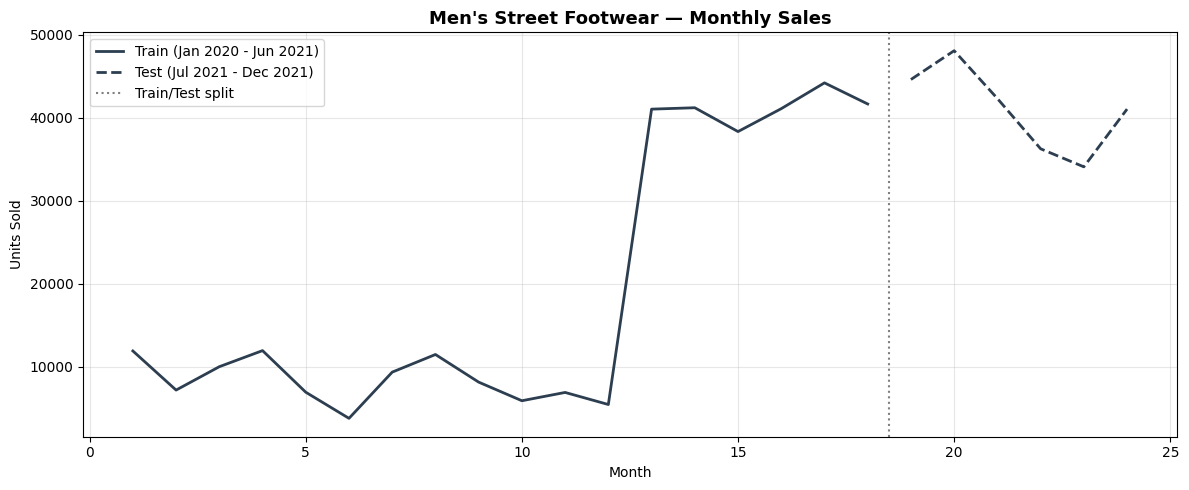

Observation: big structural break around month 13 — likely COVID recovery effect


In [7]:
# VISUALISE THE TIME SERIES
# Always plot the data before forecasting
# This helps identify trends, seasonality and structural breaks

import matplotlib.pyplot as plt
import numpy as np

months_all = list(range(1, 25))
months_train = list(range(1, 19))
months_test  = list(range(19, 25))

plt.figure(figsize=(12, 5))
plt.plot(months_train, train, color='#2C3E50', linewidth=2, label='Train (Jan 2020 - Jun 2021)')
plt.plot(months_test,  test,  color='#2C3E50', linewidth=2, linestyle='--', label='Test (Jul 2021 - Dec 2021)')
plt.axvline(x=18.5, color='gray', linestyle=':', linewidth=1.5, label='Train/Test split')
plt.title("Men's Street Footwear — Monthly Sales", fontweight='bold', fontsize=13)
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Observation: big structural break around month 13 — likely COVID recovery effect")

### Observation

The series shows a clear **structural break around month 12-13**, likely driven by post-COVID demand recovery.

With only **24 months of data**, seasonality and trend are difficult to identify clearly.

This will impact forecast accuracy  **high MAPE is expected**.
We proceed with all available data and document this as a known limitation.

### Forecasting Comparing 3 Methods

We apply 3 forecasting methods to the test period (Jul - Dec 2021):
- **Naive:** predicts next month = last observed value
- **Moving Average (3m):** average of last 3 months
- **Exponential Smoothing:** weighted average, more weight to recent months

Each method generates 6 predictions (one per test month).
We will then evaluate accuracy using MAPE and BIAS.

In [8]:

# FORECASTING + ERROR METRICS
# Apply 3 forecasting methods and calculate demand planning KPIs:
# Detailed table per month + Summary KPIs (MAE, MAPE, SMAPE, RMSE, BIAS, MASE, Accuracy)
# Moving Average is ROLLING — each month uses previous 3 real values

import numpy as np
import pandas as pd

# ── Forecasts ──────────────────────────────────────────────────────────────
months_test_labels = ['Jul 2021','Aug 2021','Sep 2021','Oct 2021','Nov 2021','Dec 2021']
actual = [float(v) for v in test]

# Method 1 — Naive: repeat last observed value from train
fc_naive = [float(train[-1])] * 6

# Method 2 — Rolling Moving Average (3m): each month uses previous 3 real values
fc_ma = []
history = list(train)
for i in range(6):
    ma = round(np.mean(history[-3:]))
    fc_ma.append(float(ma))
    history.append(actual[i])  # add real value for next prediction

# Method 3 — Exponential Smoothing (alpha=0.3)
alpha = 0.3
s = float(train[0])
for val in train[1:]:
    s = alpha * float(val) + (1 - alpha) * s
fc_es = [round(s)] * 6

# ── Detailed table — ordered by METHOD then chronologically ───────────────
rows = []
for method, fc in [('Naive', fc_naive), ('Rolling_MA_3m', fc_ma), ('Exp_Smooth', fc_es)]:
    for i in range(6):
        a     = actual[i]
        f     = float(fc[i])
        err   = f - a
        ae    = abs(err)
        ape   = ae / a * 100
        smape = ae / ((abs(a) + abs(f)) / 2) * 100
        se    = err ** 2
        rows.append({
            'Month_order':  i,
            'Method_order': ['Naive','Rolling_MA_3m','Exp_Smooth'].index(method),
            'Month':        months_test_labels[i],
            'Method':       method,
            'Actual':       int(a),
            'Forecast':     int(f),
            'Error':        round(err, 0),
            'AE':           round(ae, 0),
            'APE_%':        round(ape, 1),
            'SMAPE_%':      round(smape, 1),
            'SE':           round(se, 0)
        })

detail_df = pd.DataFrame(rows)
detail_df = detail_df.sort_values(['Method_order','Month_order'])
detail_df = detail_df.drop(columns=['Month_order','Method_order']).reset_index(drop=True)

print("═" * 82)
print("DETAILED FORECAST vs ACTUALS — Error Metrics per Month")
print("═" * 82)
print(detail_df.to_string(index=False))

# ── MASE benchmark ─────────────────────────────────────────────────────────
naive_train_errors = [abs(float(train[i]) - float(train[i-1]))
                      for i in range(1, len(train))]
mae_naive_train = np.mean(naive_train_errors)

# ── Summary KPIs ───────────────────────────────────────────────────────────
summary_rows = []
for method in ['Naive', 'Rolling_MA_3m', 'Exp_Smooth']:
    sub   = detail_df[detail_df['Method'] == method]
    mae   = round(sub['AE'].mean(), 0)
    mape  = round(sub['APE_%'].mean(), 1)
    smape = round(sub['SMAPE_%'].mean(), 1)
    rmse  = round(np.sqrt(sub['SE'].mean()), 0)
    bias  = round(sub['Error'].mean() / sub['Actual'].mean() * 100, 1)
    mase  = round(mae / mae_naive_train, 2)
    fa    = round(max(0, 100 - mape), 1)
    summary_rows.append({
        'Method':              method,
        'MAE':                 mae,
        'MAPE_%':              mape,
        'SMAPE_%':             smape,
        'RMSE':                rmse,
        'BIAS_%':              bias,
        'MASE':                mase,
        'Forecast_Accuracy_%': fa
    })

summary_df = pd.DataFrame(summary_rows)

print("\n" + "═" * 75)
print("SUMMARY KPIs BY METHOD")
print("═" * 75)
print(summary_df.to_string(index=False))

# ── Best method ────────────────────────────────────────────────────────────
best_idx = summary_df['MAPE_%'].idxmin()
best     = summary_df.loc[best_idx]
print(f"\n Best method: {best['Method']}")
print(f"   MAE:               {best['MAE']}")
print(f"   MAPE:              {best['MAPE_%']}%")
print(f"   SMAPE:             {best['SMAPE_%']}%")
print(f"   RMSE:              {best['RMSE']}")
print(f"   BIAS:              {best['BIAS_%']}%")
print(f"   MASE:              {best['MASE']} {' beats Naive benchmark' if best['MASE'] < 1 else '❌ Naive benchmark wins'}")
print(f"   Forecast Accuracy: {best['Forecast_Accuracy_%']}%")

══════════════════════════════════════════════════════════════════════════════════
DETAILED FORECAST vs ACTUALS — Error Metrics per Month
══════════════════════════════════════════════════════════════════════════════════
   Month        Method  Actual  Forecast    Error      AE  APE_%  SMAPE_%          SE
Jul 2021         Naive   44625     41675  -2950.0  2950.0    6.6      6.8   8702500.0
Aug 2021         Naive   48094     41675  -6419.0  6419.0   13.3     14.3  41203561.0
Sep 2021         Naive   42335     41675   -660.0   660.0    1.6      1.6    435600.0
Oct 2021         Naive   36279     41675   5396.0  5396.0   14.9     13.8  29116816.0
Nov 2021         Naive   34104     41675   7571.0  7571.0   22.2     20.0  57320041.0
Dec 2021         Naive   41059     41675    616.0   616.0    1.5      1.5    379456.0
Jul 2021 Rolling_MA_3m   44625     42336  -2289.0  2289.0    5.1      5.3   5239521.0
Aug 2021 Rolling_MA_3m   48094     43507  -4587.0  4587.0    9.5     10.0  21040569.0
Sep 2

###  Results Interpretation — Men's Street Footwear

**Best method: Naive** with the lowest MAPE (10.0%) and highest Forecast Accuracy (90.0%)

Key insights:

- **Naive and MA(3m)** perform almost identically — MAPE 10.0% vs 10.2%
- **Exp. Smoothing** underperforms — MAPE 11.8% and negative BIAS (-8.4%)
  meaning it systematically overforecasts  risk of excess stock
- **MASE = 0.83** for Naive : the model beats the naive benchmark
- **BIAS = +1.4%** for Naive : very balanced, slight underforecast : low stockout risk

**Business implication:**
The series behaves like a stable plateau after the post-COVID recovery.
In this context, simple methods outperform complex ones.
For a demand planner, this means: monitor BIAS monthly and
adjust the forecast manually when commercial input (promotions,
new store openings) is available — exactly the S&OP process.

###  Forecast vs Actuals — Visual Comparison

The chart below shows actual sales (test period) vs the 3 forecasting methods.
The vertical line marks the train/test split.
This helps identify which method tracks actual demand most closely.

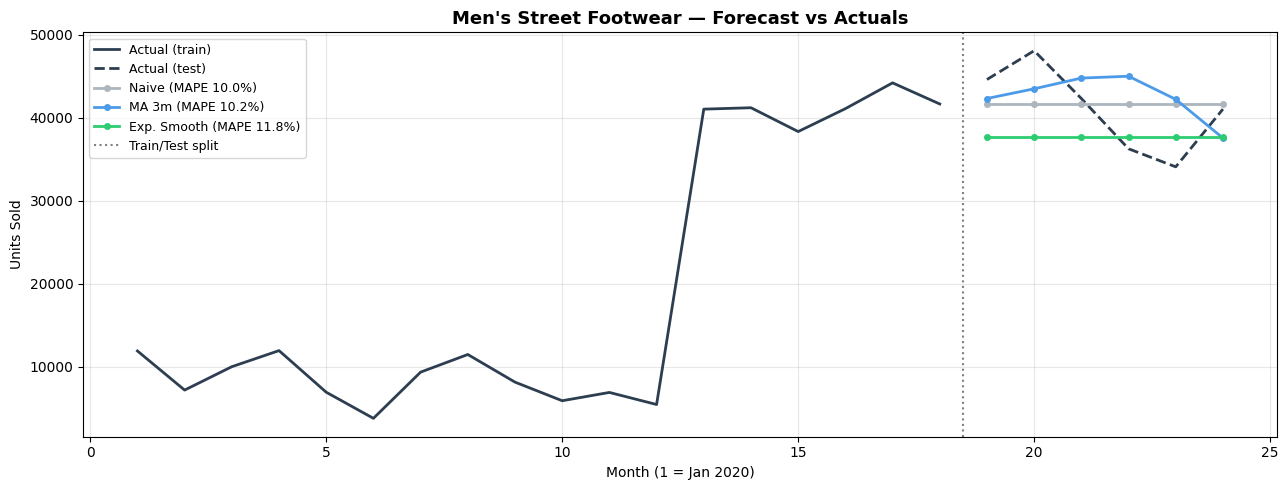

In [9]:
# VISUALISE FORECAST vs ACTUALS
# Plot actual vs predicted values for all 3 methods


import matplotlib.pyplot as plt

months_all   = list(range(1, 25))
months_train = list(range(1, 19))
months_test  = list(range(19, 25))

plt.figure(figsize=(13, 5))

# Train actuals
plt.plot(months_train, train,
         color='#2C3E50', linewidth=2, label='Actual (train)')

# Test actuals
plt.plot(months_test, actual,
         color='#2C3E50', linewidth=2, linestyle='--', label='Actual (test)')

# Forecasts
plt.plot(months_test, fc_naive,
         color='#ADB5BD', linewidth=2, marker='o', markersize=4, label=f'Naive (MAPE 10.0%)')
plt.plot(months_test, fc_ma,
         color='#4C9BE8', linewidth=2, marker='o', markersize=4, label=f'MA 3m (MAPE 10.2%)')
plt.plot(months_test, fc_es,
         color='#2ECC71', linewidth=2, marker='o', markersize=4, label=f'Exp. Smooth (MAPE 11.8%)')

# Train/test split line
plt.axvline(x=18.5, color='gray', linestyle=':', linewidth=1.5, label='Train/Test split')

plt.title("Men's Street Footwear — Forecast vs Actuals",
          fontweight='bold', fontsize=13)
plt.xlabel('Month (1 = Jan 2020)')
plt.ylabel('Units Sold')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Visual Interpretation

- **Naive and MA(3m)** track actual demand closely in the test period
- **Exp. Smoothing** consistently underestimates — negative BIAS confirmed visually
- The structural break (month 12-13) is clearly visible — post-COVID demand recovery
- All 3 methods produce flat forecasts — limitation of simple methods with short history
- A more sophisticated model (ARIMA, ETS with trend) could better capture
  the upward movement in the test period